# Stage 1 — Noiseless lensed mock (and recovery check)

This stage generates intrinsic and noiseless lensed mock cubes using the truth lens and source parameters. As a sanity check, it fits each lensed cube with the parameters selected in `mock_stage1.toml`.

1. generate the physical mass cases and intrinsic source cubes;
2. map them through the lens and inspect the lensed cubes and save them for the followed stages;
3. fit the noiseless lensed cubes without a PSF or noise.

Mass, source, and lens parameters can each be fixed to truth or made free through the TOML configuration.

In [1]:
import hashlib
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from astropy.table import Table
from astropy.constants import c as cspeed

from glint.inference import run_least_squares, run_parallel_fits
from glint.model_parameters import MASS_PARAMETER_NAMES, ParameterLayout
from glint.pressure_support import UnphysicalPressureSupportError
from glint.plotstyle import set_my_plot_style

set_my_plot_style()

%matplotlib inline

print("Place mock_truth.toml and mock_stage1.toml in the same directory as this notebook.")
EXAMPLE_DIR = Path.cwd().resolve()
if EXAMPLE_DIR.name == 'examples':
    EXAMPLE_DIR = EXAMPLE_DIR / 'forward_mass'
if not (EXAMPLE_DIR.name == 'forward_mass' and EXAMPLE_DIR.parent.name == 'examples'):
    raise FileNotFoundError('Run this notebook from examples/forward_mass or examples.')
if str(EXAMPLE_DIR) not in sys.path:
    sys.path.insert(0, str(EXAMPLE_DIR))

import forward_mass_common as fmc


Place mock_truth.toml and mock_stage1.toml in the same directory as this notebook.


## Configuration

`mock_truth.toml` contains every parameter used to generate the mock data. It is the single source of truth shared by the later stages. `mock_stage1.toml` is read only for the optional noiseless recovery check at the end.

The parameters are grouped into:

- **mass parameters**: disk, bulge, and NFW halo;
- **source parameters**: position, flux profile, orientation, and velocity dispersion;
- **lens parameters**: fixed SIE + external shear/convergence.

In [2]:
TRUTH_CONFIG = fmc.load_toml(EXAMPLE_DIR / 'mock_truth.toml')
SOURCE_REDSHIFT = float(TRUTH_CONFIG['target']['redshift'])

# Mock生成に使うtruthのForwardModel。vertical modelもtruthのものを使う (fit側のmodel選択は各Stage TOMLが持つ）。
TRUTH_MODEL = fmc.build_forward_model(TRUTH_CONFIG, TRUTH_CONFIG)

print(f'z = {SOURCE_REDSHIFT:.3f}')
print(f'kpc/arcsec = {TRUTH_MODEL.kpc_per_arcsec:.4f}')
print(f'rho_critical = {TRUTH_MODEL.critical_density_msun_kpc3:.4e} Msun/kpc^3')


z = 6.024
kpc/arcsec = 5.6972
rho_critical = 1.4262e+04 Msun/kpc^3


## Independent source- and image-plane grids

The intrinsic source and lensed image are evaluated on separate grids:

- the **source-plane grid** resolves the galaxy before lensing;
- the **image-plane grid** covers the larger lensed field supplied to later observing simulations;
- the **radial grid** is a one-dimensional grid used to tabulate the rotation curve, surface brightness, and velocity dispersion.

The source grid is three times finer than the image grid for numerical interpolation. This is an oversampling choice; a total magnification near nine does not imply an isotropic factor-of-three physical resolution gain everywhere. The local lens Jacobian determines the directional resolution.

In [3]:
# 幾何・スペクトル軸はTRUTH_MODELが保持している。後段のFITS書き出しで使う別名を置く。
source_grid_cfg = TRUTH_CONFIG['grid']['source']
image_grid_cfg = TRUTH_CONFIG['grid']['image']
spectral_cfg = TRUTH_CONFIG['spectral']

XX_SOURCE_ARCSEC, YY_SOURCE_ARCSEC = TRUTH_MODEL.xx_src, TRUTH_MODEL.yy_src
XX_IMAGE_ARCSEC, YY_IMAGE_ARCSEC = TRUTH_MODEL.xx_img, TRUTH_MODEL.yy_img
RADIUS_ARCSEC = TRUTH_MODEL.radius_arcsec
RADIUS_MAX_ARCSEC = RADIUS_ARCSEC[-1]
RADIUS_KPC = TRUTH_MODEL.radius_kpc
VELOCITY_CHANNELS_KMS = TRUTH_MODEL.vchan_kms

source_truth = TRUTH_CONFIG['truth']['source']
lens_truth = TRUTH_CONFIG['truth']['lens']

print('source cube:', (VELOCITY_CHANNELS_KMS.size, *XX_SOURCE_ARCSEC.shape),
      f"at {source_grid_cfg['pixel_size_arcsec']:.5f} arcsec/pixel")
print('image cube: ', (VELOCITY_CHANNELS_KMS.size, *XX_IMAGE_ARCSEC.shape),
      f"at {image_grid_cfg['pixel_size_arcsec']:.3f} arcsec/pixel")
print(f'radial grid: 0--{RADIUS_MAX_ARCSEC:.3f} arcsec '
      f'({RADIUS_KPC[-1]:.3f} kpc), step={TRUTH_CONFIG["radial_profile"]["radial_step_arcsec"]:.3f} arcsec')


source cube: (33, 200, 200) at 0.01000 arcsec/pixel
image cube:  (33, 200, 200) at 0.030 arcsec/pixel
radial grid: 0--0.880 arcsec (5.014 kpc), step=0.010 arcsec


## Physical mass cases

Each case changes the bulge-to-total baryonic mass ratio and bulge effective radius while keeping the total baryonic mass, disk scale radius, and halo mass fixed. The optional `bt00` case contains no bulge; its bulge radius is therefore physically undefined and stored as `NaN` internally.

`truth_parameters()` combines the case-dependent mass parameters with the common source and lens truth values. This gives every forward-model call the same flat parameter dictionary.

The case-name formatter remains local because it is an examples-only output convention, not part of the scientific `glint` API.

In [4]:
CASES = fmc.make_cases(TRUTH_CONFIG)


def truth_parameters(case):
    return fmc.truth_parameters(case, TRUTH_CONFIG)


Table(
    rows=[(case['name'], *(case[name] for name in MASS_PARAMETER_NAMES)) for case in CASES],
    names=('case', *MASS_PARAMETER_NAMES),
)


case,log10_m_baryon,disk_scale_radius_kpc,log10_m200,bulge_to_total,bulge_effective_radius_kpc
str9,float64,float64,float64,float64,float64
bt10_re03,11.0,1.0,11.477121254719663,0.1,0.3
bt10_re06,11.0,1.0,11.477121254719663,0.1,0.6
bt25_re03,11.0,1.0,11.477121254719663,0.25,0.3
bt25_re06,11.0,1.0,11.477121254719663,0.25,0.6
bt50_re03,11.0,1.0,11.477121254719663,0.5,0.3
bt50_re06,11.0,1.0,11.477121254719663,0.5,0.6
bt00,11.0,1.0,11.477121254719663,0.0,nan


## Physical source-cube model

The empirical Courteau rotation curve is not used. Circular-speed contributions are calculated directly from the exponential disk, Hernquist bulge, and NFW halo and are added in quadrature by `mass_rotation_curve`.

The intrinsic cube is then constructed from:

1. the physical rotation curve;
2. an exponential radial surface-brightness profile;
3. an exponential radial velocity-dispersion profile;
4. the source position, inclination, position angle, and systemic velocity.

All source parameters are read from the shared truth file; later stages can choose which of them are free without changing the cube generator.

In [5]:
# Forward chain（mass model → intrinsic cube → lensed cube）の実体は
# glint.forward.ForwardModelへ移した。引数の説明もそちらのdocstringにある。
def rotation_curve(parameters):
    return TRUTH_MODEL.rotation_curve(parameters)


## Fixed lens mapping

Stage 1 uses the lens parameters in `mock_truth.toml` without fitting them. The SIE + external shear/convergence deflection is evaluated at every image-plane pixel, and the corresponding source coordinate is

$$\boldsymbol{\beta}=\boldsymbol{\theta}-\boldsymbol{\alpha}(\boldsymbol{\theta}).$$

The intrinsic source cube is interpolated at these coordinates. Surface brightness is conserved by lensing; multiplication by the image-pixel area converts the mapped values from Jy arcsec$^{-2}$ to Jy pixel$^{-1}$.

Critical lines live in the image plane, whereas their mapped caustics live in the source plane. The analytic SIE + external-shear Jacobian is used to calculate both.

In [6]:
# Truth lensのcritical linesとcaustics
REFERENCE_PARAMETERS = truth_parameters(CASES[0])
CRITICAL_LINES, CAUSTICS = TRUTH_MODEL.critical_lines_and_caustics(
    REFERENCE_PARAMETERS, min_points=10, min_length=0.05,
)
print('critical-line segments:', len(CRITICAL_LINES))
print('caustic segments:', len(CAUSTICS))


critical-line segments: 1
caustic segments: 1


## Intrinsic and lensed mock cubes

For every mass case, this section creates:

- `INTRINSIC_CUBES`: source-plane surface brightness in Jy arcsec$^{-2}$;
- `LENSED_CUBES`: image-plane flux in Jy pixel$^{-1}$.

No PSF and no noise are applied. Consequently Stage 1 has no meaningful S/N value; peak S/N is introduced in Stage 2.

The tabulated magnification is the ratio of total lensed flux to total intrinsic flux. The intrinsic sum must be multiplied by the source-pixel area, while the lensed cube already contains flux per image pixel.

In [7]:
TRUTH_PARAMETERS = {case['name']: truth_parameters(case) for case in CASES}
INTRINSIC_CUBES = {
    case['name']: TRUTH_MODEL.make_intrinsic_cube(TRUTH_PARAMETERS[case['name']])
    for case in CASES
}
LENSED_CUBES = {
    case['name']: TRUTH_MODEL.make_lensed_cube(TRUTH_PARAMETERS[case['name']])
    for case in CASES
}

# Compare integrated fluxes; the source cube still needs its pixel-area factor.
magnification_rows = []
for case in CASES:
    source_flux = (
        INTRINSIC_CUBES[case['name']].sum()
        * TRUTH_MODEL.pixsize_src**2
    )
    lensed_flux = LENSED_CUBES[case['name']].sum()
    magnification_rows.append((case['name'], source_flux, lensed_flux, lensed_flux / source_flux))

MAGNIFICATION_TABLE = Table(
    rows=magnification_rows,
    names=('case', 'intrinsic_flux', 'lensed_flux', 'flux_magnification'),
)
for name in MAGNIFICATION_TABLE.colnames[1:]:
    MAGNIFICATION_TABLE[name].format = '.5g'
MAGNIFICATION_TABLE


case,intrinsic_flux,lensed_flux,flux_magnification
str9,float32,float32,float32
bt10_re03,0.19539,1.7053,8.7276
bt10_re06,0.19539,1.7053,8.7276
bt25_re03,0.19539,1.7053,8.7276
bt25_re06,0.19539,1.7053,8.7276
bt50_re03,0.19482,1.7002,8.7272
bt50_re06,0.19539,1.7053,8.7276
bt00,0.19539,1.7053,8.7276


## Save reusable mock cubes

Each case is written once so that later stages do not regenerate the galaxy or lens mapping:

- `intrinsic_source_cube.fits`: source-plane cube for inspection;
- `lensed_sky_cube.fits`: celestial-WCS cube used by Stage 2 and CASA `simobserve`;
- `mock_manifest.json`: relative file paths, truth parameters, grids, spectral setup, and SHA-256 hashes.

The hashes allow downstream notebooks to detect whether their input mock data changed. CASA needs a sky-coordinate WCS, so only the lensed FITS uses RA/Dec axes.

In [8]:
C_KMS = cspeed.to('km/s').value
CASA_SPECTRAL_FRAME = str(spectral_cfg["spectral_frame"])
# CASA uses BARY, while the FITS spectral-WCS spelling is BARYCENT.
FITS_SPECTRAL_FRAME = {"BARY": "BARYCENT"}.get(
    CASA_SPECTRAL_FRAME, CASA_SPECTRAL_FRAME,
)


def frequencies_from_radio_velocity(velocity_kms, reference_frequency_hz):
    return reference_frequency_hz * (1.0 - np.asarray(velocity_kms) / C_KMS)


def write_intrinsic_source_fits(path, cube):
    """Save the intrinsic source-plane surface-brightness cube."""
    frequencies_hz = frequencies_from_radio_velocity(
        VELOCITY_CHANNELS_KMS, REFERENCE_FREQUENCY_HZ,
    )
    ny, nx = cube.shape[-2:]
    header = fits.Header()
    header["BUNIT"] = "Jy/arcsec2"
    header["BTYPE"] = "Intensity"
    header["SPECSYS"] = FITS_SPECTRAL_FRAME
    header["RESTFRQ"] = REFERENCE_FREQUENCY_HZ
    header["CTYPE1"] = "XOFFSET"
    header["CTYPE2"] = "YOFFSET"
    header["CTYPE3"] = "FREQ"
    header["CUNIT1"] = "arcsec"
    header["CUNIT2"] = "arcsec"
    header["CUNIT3"] = "Hz"
    # make_grid_arcsec places the origin at zero-based index n/2; FITS is one-based.
    header["CRPIX1"] = nx / 2.0 + 1.0
    header["CRPIX2"] = ny / 2.0 + 1.0
    header["CRPIX3"] = 1.0
    header["CRVAL1"] = source_grid_cfg["x_center_arcsec"]
    header["CRVAL2"] = source_grid_cfg["y_center_arcsec"]
    header["CRVAL3"] = frequencies_hz[0]
    header["CDELT1"] = source_grid_cfg["pixel_size_arcsec"]
    header["CDELT2"] = source_grid_cfg["pixel_size_arcsec"]
    header["CDELT3"] = np.median(np.diff(frequencies_hz))
    fits.writeto(path, np.asarray(cube, dtype=np.float32), header, overwrite=True)


def write_lensed_sky_fits(path, cube):
    """Save the image-plane lensed cube with celestial WCS for CASA."""
    frequencies_hz = frequencies_from_radio_velocity(
        VELOCITY_CHANNELS_KMS, REFERENCE_FREQUENCY_HZ,
    )
    ny, nx = cube.shape[-2:]
    target = TRUTH_CONFIG["target"]
    header = fits.Header()
    header["BUNIT"] = "Jy/pixel"
    header["BTYPE"] = "Intensity"
    header["RADESYS"] = target["coordinate_frame"]
    header["SPECSYS"] = FITS_SPECTRAL_FRAME
    header["RESTFRQ"] = REFERENCE_FREQUENCY_HZ
    header["CTYPE1"] = "RA---TAN"
    header["CTYPE2"] = "DEC--TAN"
    header["CTYPE3"] = "FREQ"
    header["CUNIT1"] = "deg"
    header["CUNIT2"] = "deg"
    header["CUNIT3"] = "Hz"
    # make_grid_arcsec places the origin at zero-based index n/2; FITS is one-based.
    header["CRPIX1"] = nx / 2.0 + 1.0
    header["CRPIX2"] = ny / 2.0 + 1.0
    header["CRPIX3"] = 1.0
    header["CRVAL1"] = target["phase_center_ra_deg"]
    header["CRVAL2"] = target["phase_center_dec_deg"]
    header["CRVAL3"] = frequencies_hz[0]
    # RA increases to the left in the standard celestial-image convention.
    header["CDELT1"] = -image_grid_cfg["pixel_size_arcsec"] / 3600.0
    header["CDELT2"] = image_grid_cfg["pixel_size_arcsec"] / 3600.0
    header["CDELT3"] = np.median(np.diff(frequencies_hz))
    fits.writeto(path, np.asarray(cube, dtype=np.float32), header, overwrite=True)


In [9]:
REST_FREQUENCY_TARGET_LINE_HZ = float(TRUTH_CONFIG["line"]["rest_frequency_hz"])
REFERENCE_FREQUENCY_HZ = REST_FREQUENCY_TARGET_LINE_HZ / (1.0 + SOURCE_REDSHIFT)
STAGE1_OUTPUT_DIR = EXAMPLE_DIR / "output" / "stage1" / "products"
STAGE1_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Store paths relative to the manifest so the output tree remains portable.
manifest_cases = []
for case in CASES:
    name = case["name"]
    case_dir = STAGE1_OUTPUT_DIR / name
    case_dir.mkdir(parents=True, exist_ok=True)
    intrinsic_path = case_dir / "intrinsic_source_cube.fits"
    lensed_path = case_dir / "lensed_sky_cube.fits"
    write_intrinsic_source_fits(intrinsic_path, INTRINSIC_CUBES[name])
    write_lensed_sky_fits(lensed_path, LENSED_CUBES[name])
    manifest_cases.append({
        "name": name,
        "parameters": {
            key: None if isinstance(value, float) and not np.isfinite(value) else value
            for key, value in TRUTH_PARAMETERS[name]._asdict().items()
        },
        "intrinsic_source_cube": str(intrinsic_path.relative_to(STAGE1_OUTPUT_DIR)),
        "lensed_sky_cube": str(lensed_path.relative_to(STAGE1_OUTPUT_DIR)),
        "intrinsic_sha256": hashlib.sha256(intrinsic_path.read_bytes()).hexdigest(),
        "lensed_sha256": hashlib.sha256(lensed_path.read_bytes()).hexdigest(),
    })

MOCK_MANIFEST = {
    "schema_version": 2,
    "target": {
        **TRUTH_CONFIG["target"],
        "rest_frequency_target_line_hz": REST_FREQUENCY_TARGET_LINE_HZ,
        "reference_frequency_hz": REFERENCE_FREQUENCY_HZ,
    },
    "image_grid": TRUTH_CONFIG["grid"]["image"],
    "source_grid": TRUTH_CONFIG["grid"]["source"],
    "pressure_support": TRUTH_CONFIG["pressure_support"],
    "spectral": {
        **TRUTH_CONFIG["spectral"],
        "velocity_channels_kms": VELOCITY_CHANNELS_KMS.tolist(),
    },
    "cases": manifest_cases,
}
MANIFEST_PATH = STAGE1_OUTPUT_DIR / "mock_manifest.json"
MANIFEST_PATH.write_text(json.dumps(MOCK_MANIFEST, indent=2, sort_keys=True))
print(f"Saved {len(manifest_cases)} mock cases and manifest to {STAGE1_OUTPUT_DIR}")


Saved 7 mock cases and manifest to /lwk/atsujita/HATLASJ0900/glint/examples/forward_mass/output/stage1/products


## Lens-mapping visualization

A representative case is shown first as velocity-integrated (moment-0) maps. Caustics are overlaid only on the source plane and critical lines only on the image plane. This provides a quick geometry check before inspecting all spectral channels.

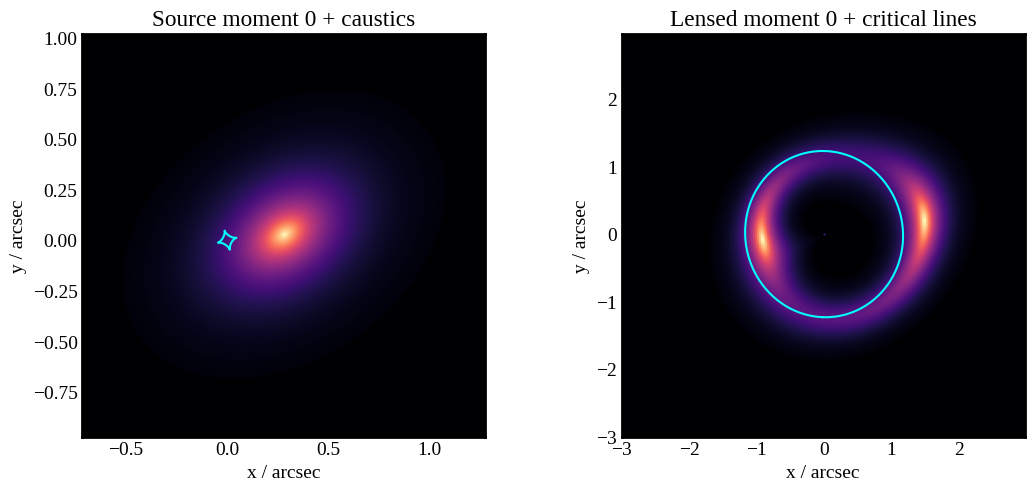

In [10]:
# 可視化には現在の設定で生成された先頭caseを使う。
reference_case = CASES[0]['name']
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), constrained_layout=True)

source_moment0 = INTRINSIC_CUBES[reference_case].sum(axis=0)
axes[0].imshow(
    source_moment0,
    origin='lower',
    cmap='magma',
    extent=(XX_SOURCE_ARCSEC.min(), XX_SOURCE_ARCSEC.max(),
            YY_SOURCE_ARCSEC.min(), YY_SOURCE_ARCSEC.max()),
)
for segment in CAUSTICS:
    axes[0].plot(segment[:, 0], segment[:, 1], color='cyan', lw=1.5)
axes[0].set_title('Source moment 0 + caustics')

lensed_moment0 = LENSED_CUBES[reference_case].sum(axis=0)
axes[1].imshow(
    lensed_moment0,
    origin='lower',
    cmap='magma',
    extent=(XX_IMAGE_ARCSEC.min(), XX_IMAGE_ARCSEC.max(),
            YY_IMAGE_ARCSEC.min(), YY_IMAGE_ARCSEC.max()),
)
for segment in CRITICAL_LINES:
    axes[1].plot(segment[:, 0], segment[:, 1], color='cyan', lw=1.5)
axes[1].set_title('Lensed moment 0 + critical lines')

for ax in axes:
    ax.set_xlabel('x / arcsec')
    ax.set_ylabel('y / arcsec')
plt.show()

## Full noiseless channel maps

Moment maps can hide velocity-dependent mistakes, so every source- and image-plane channel is displayed for every mass case. A common color scale within each cube makes changes in line morphology and amplitude across velocity directly comparable.

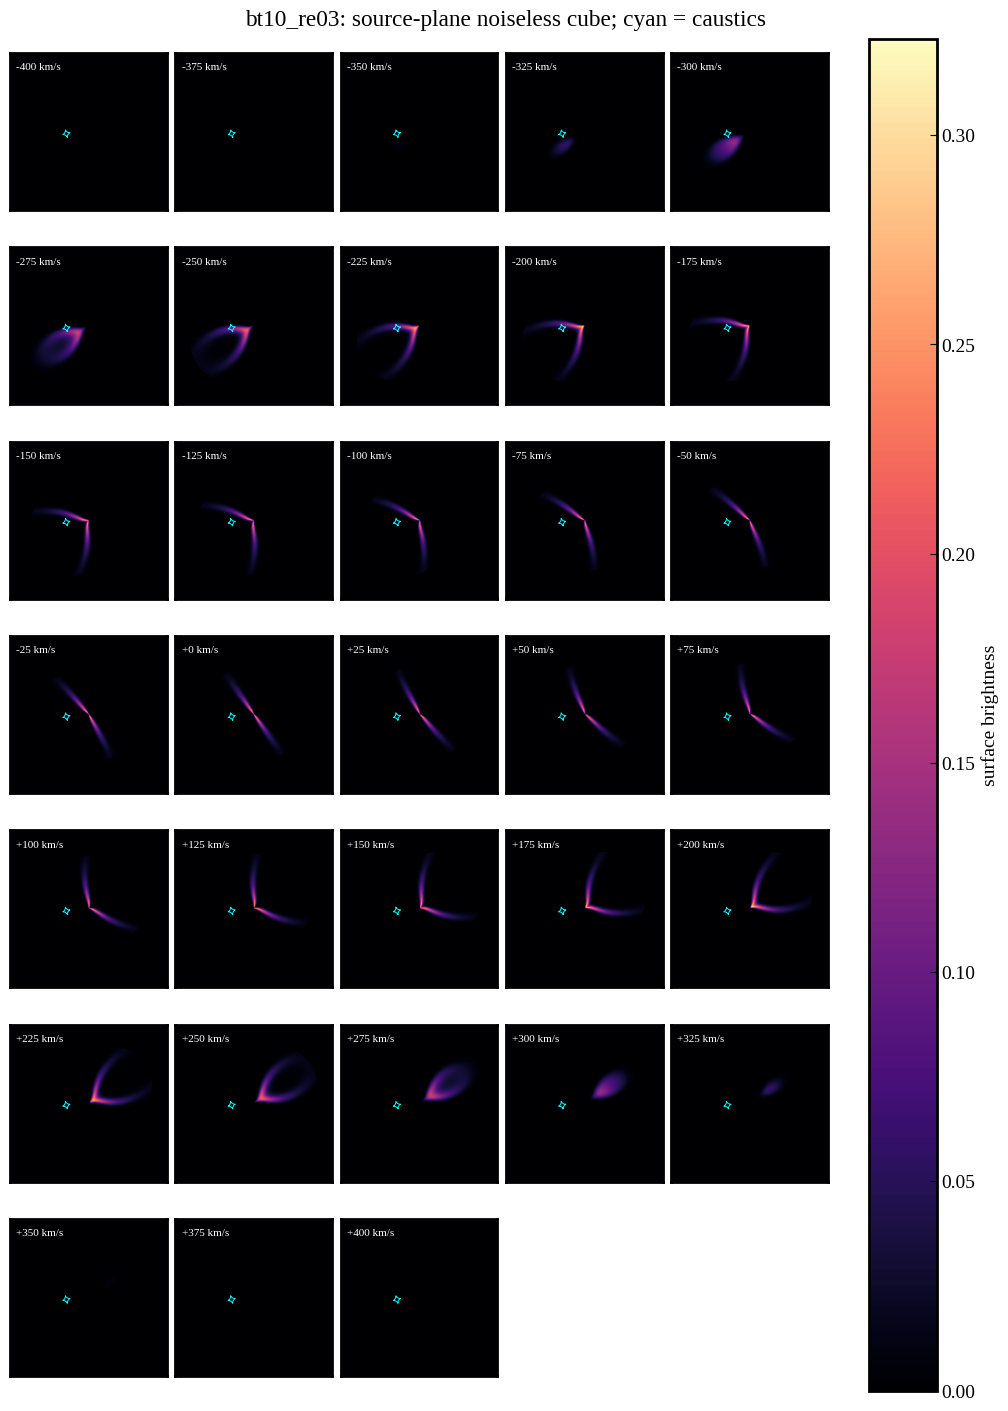

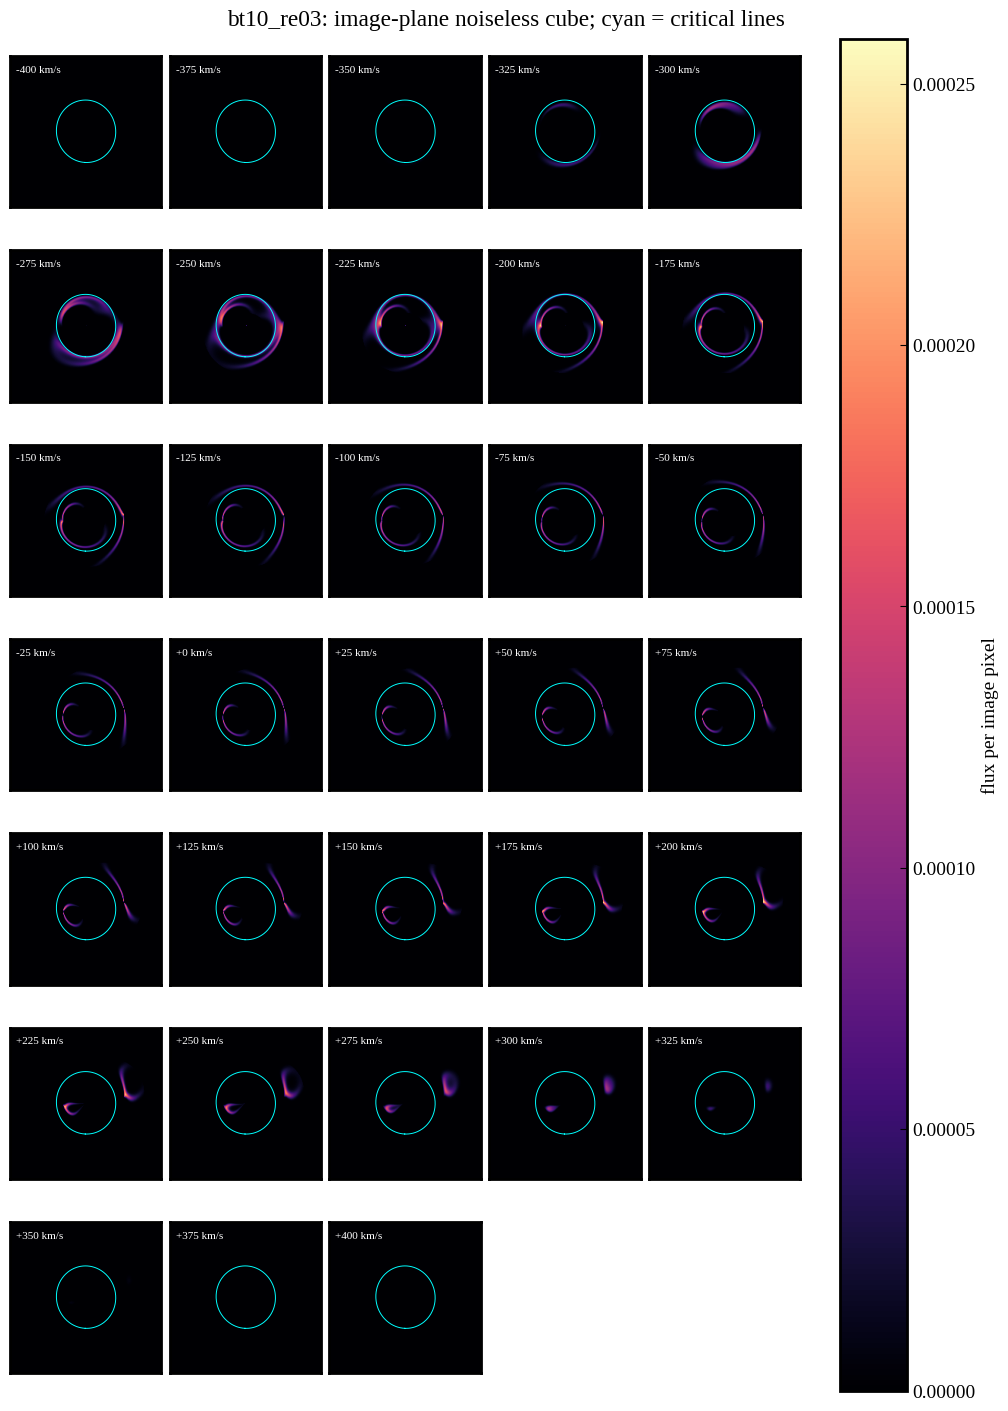

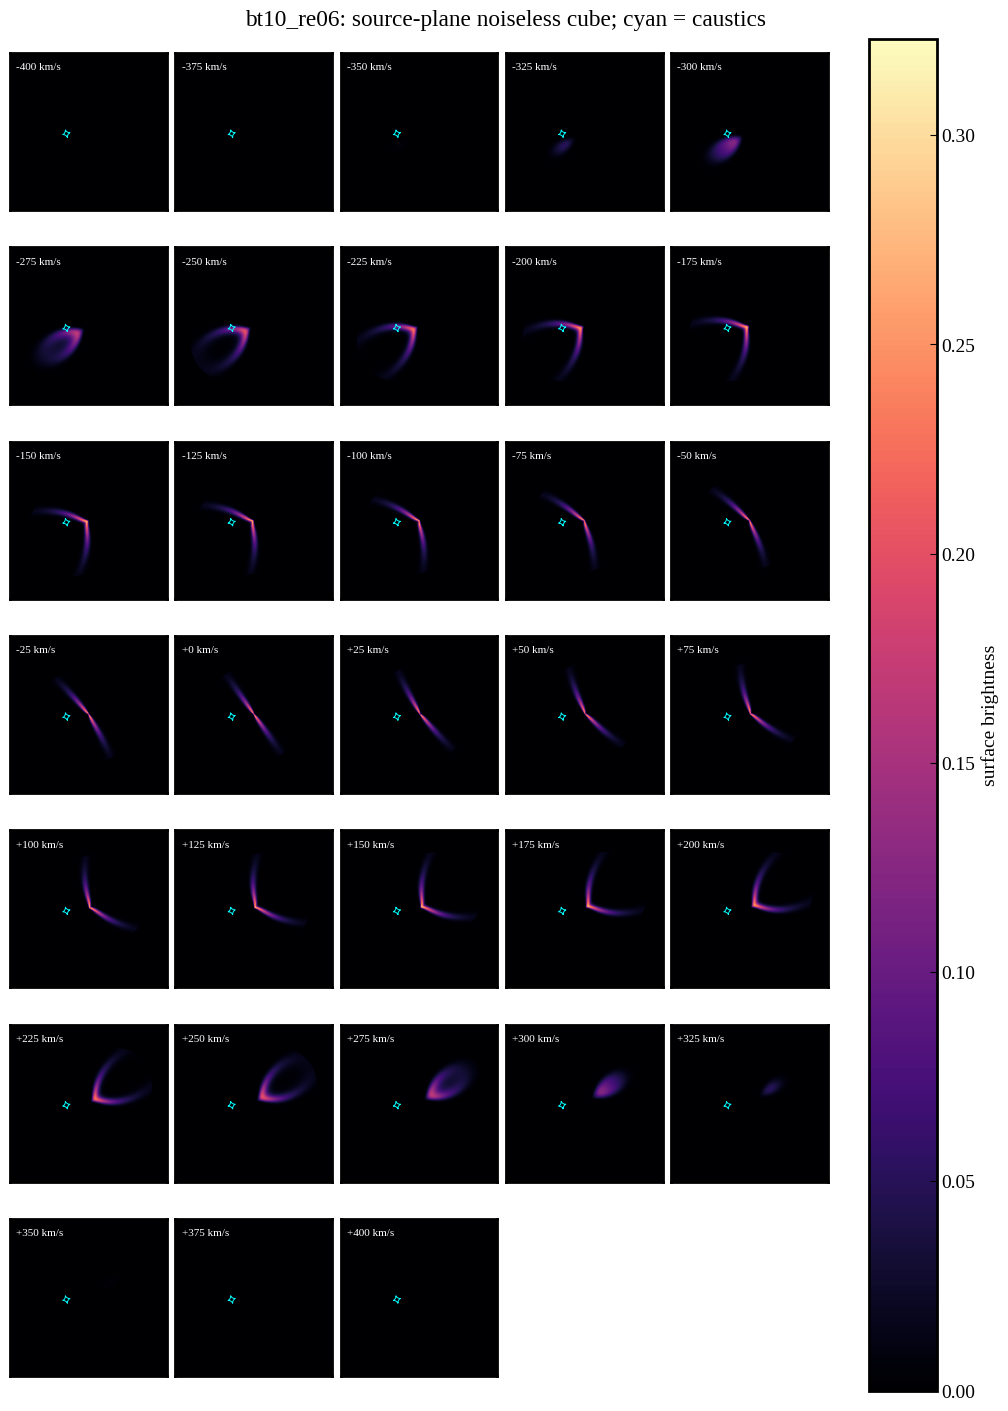

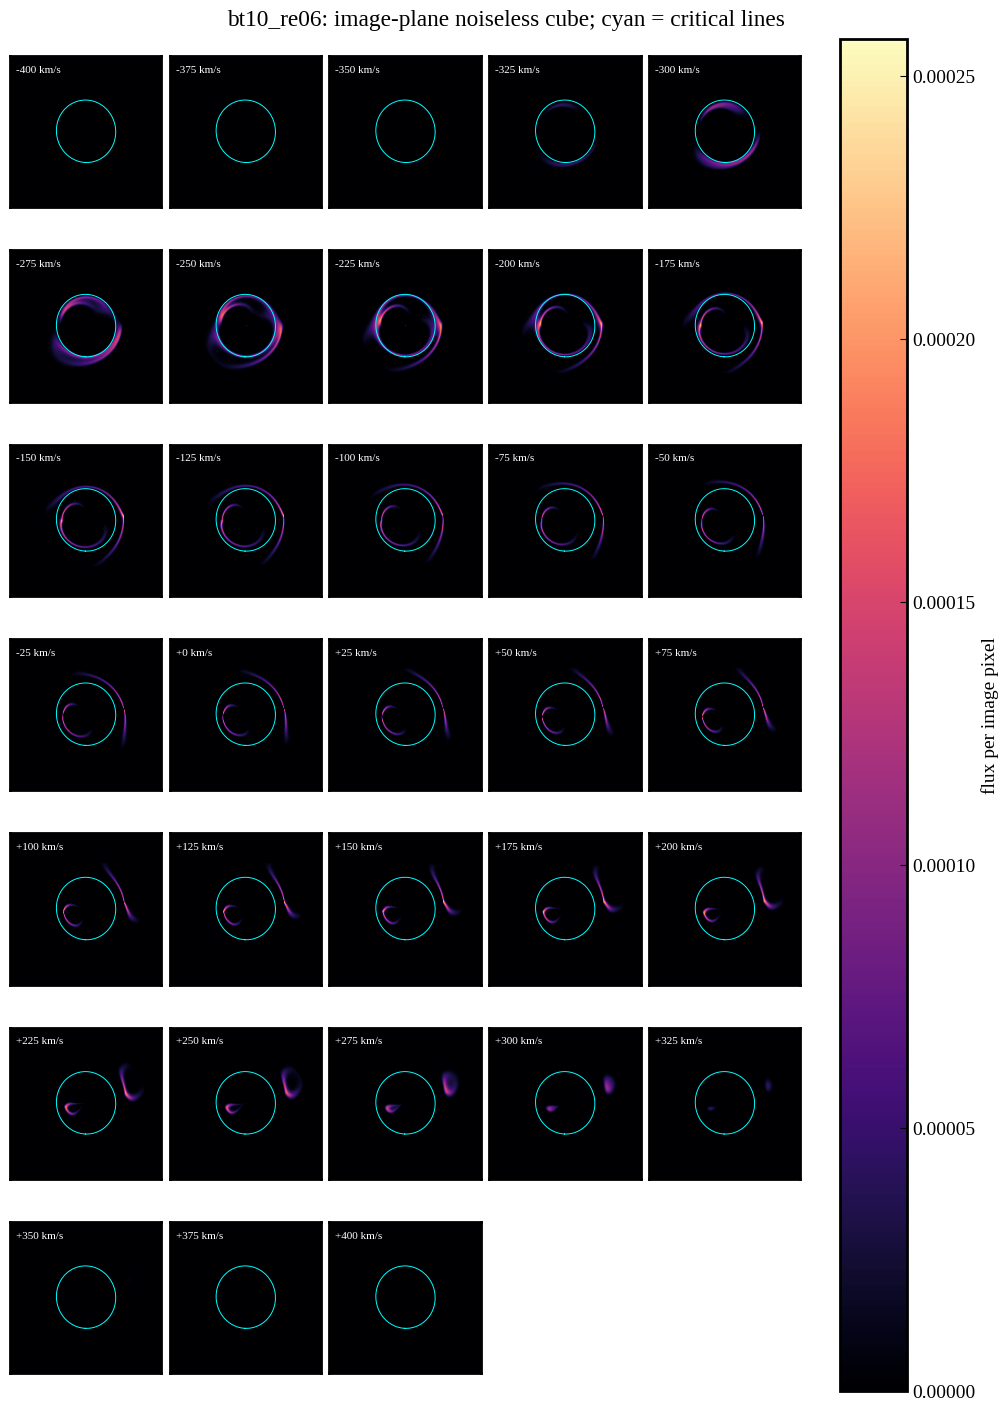

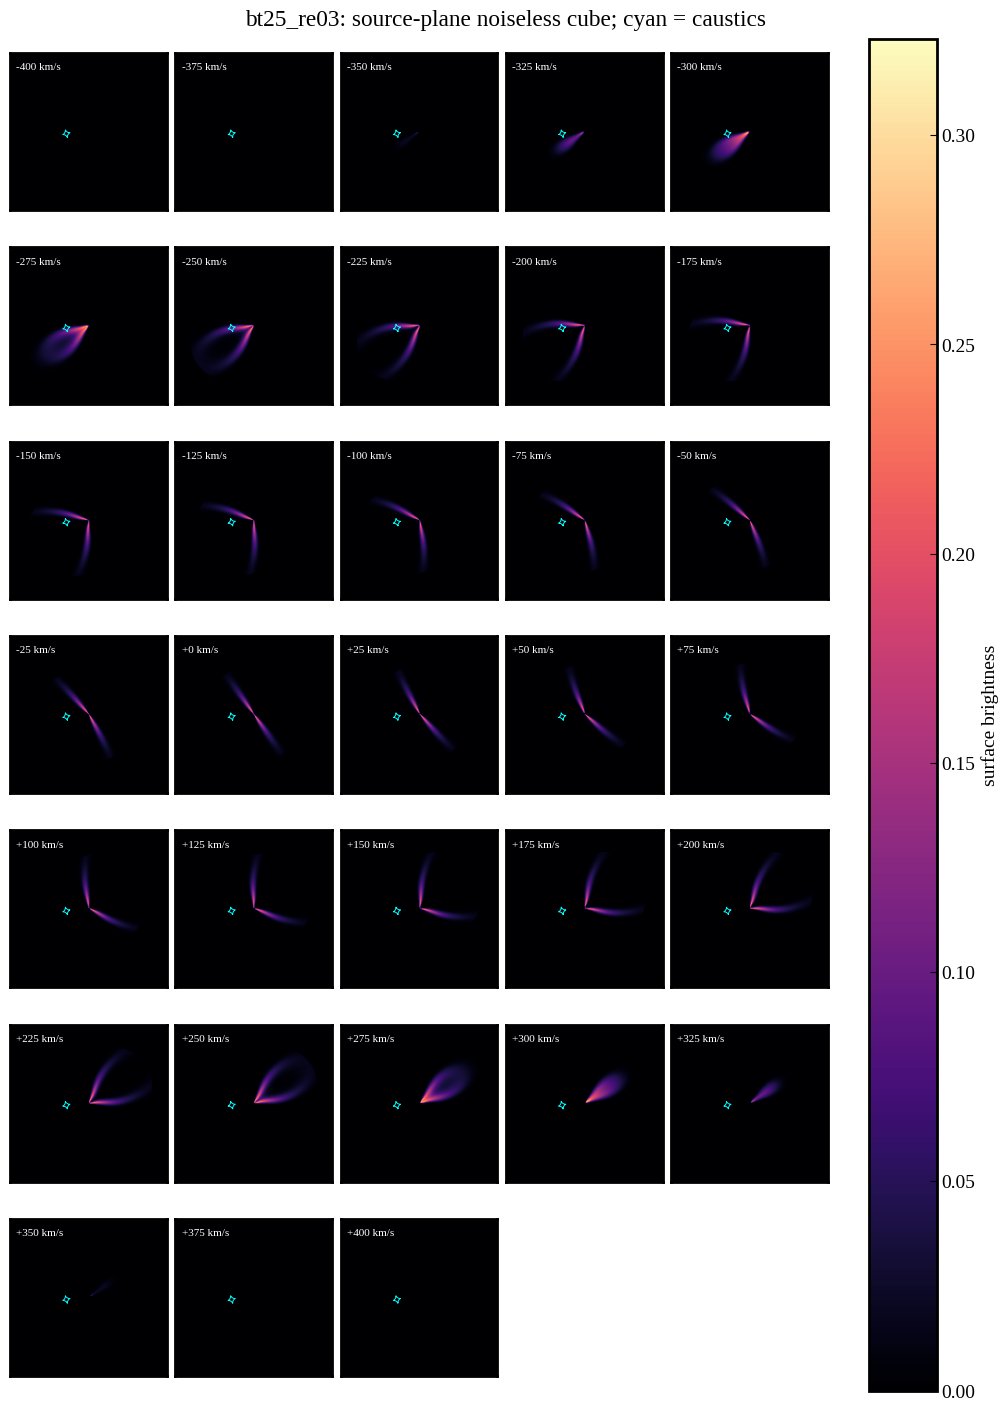

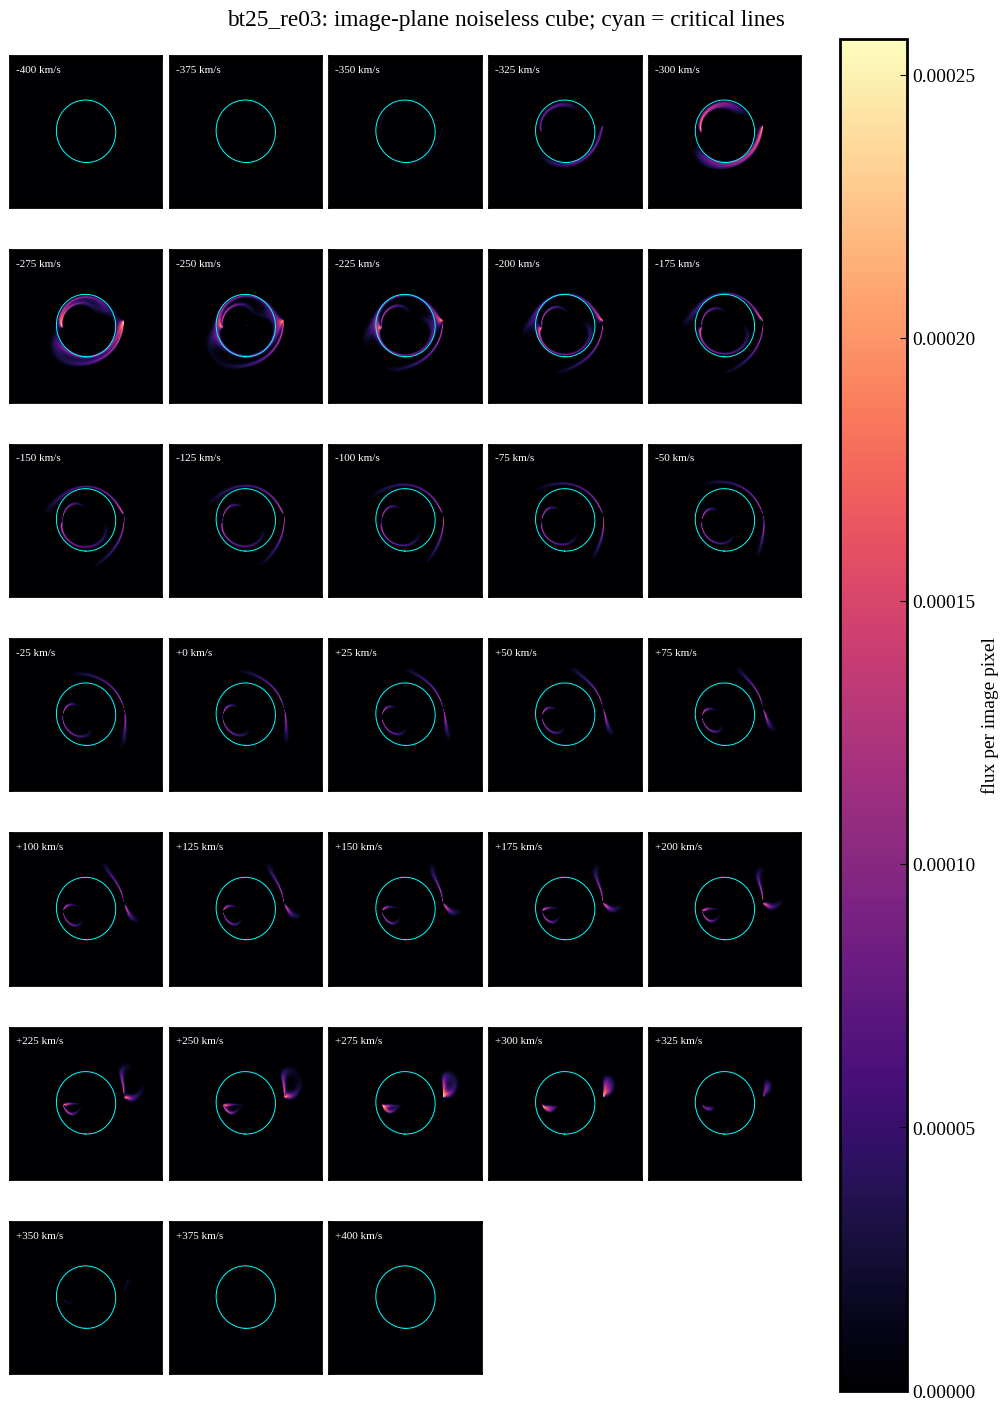

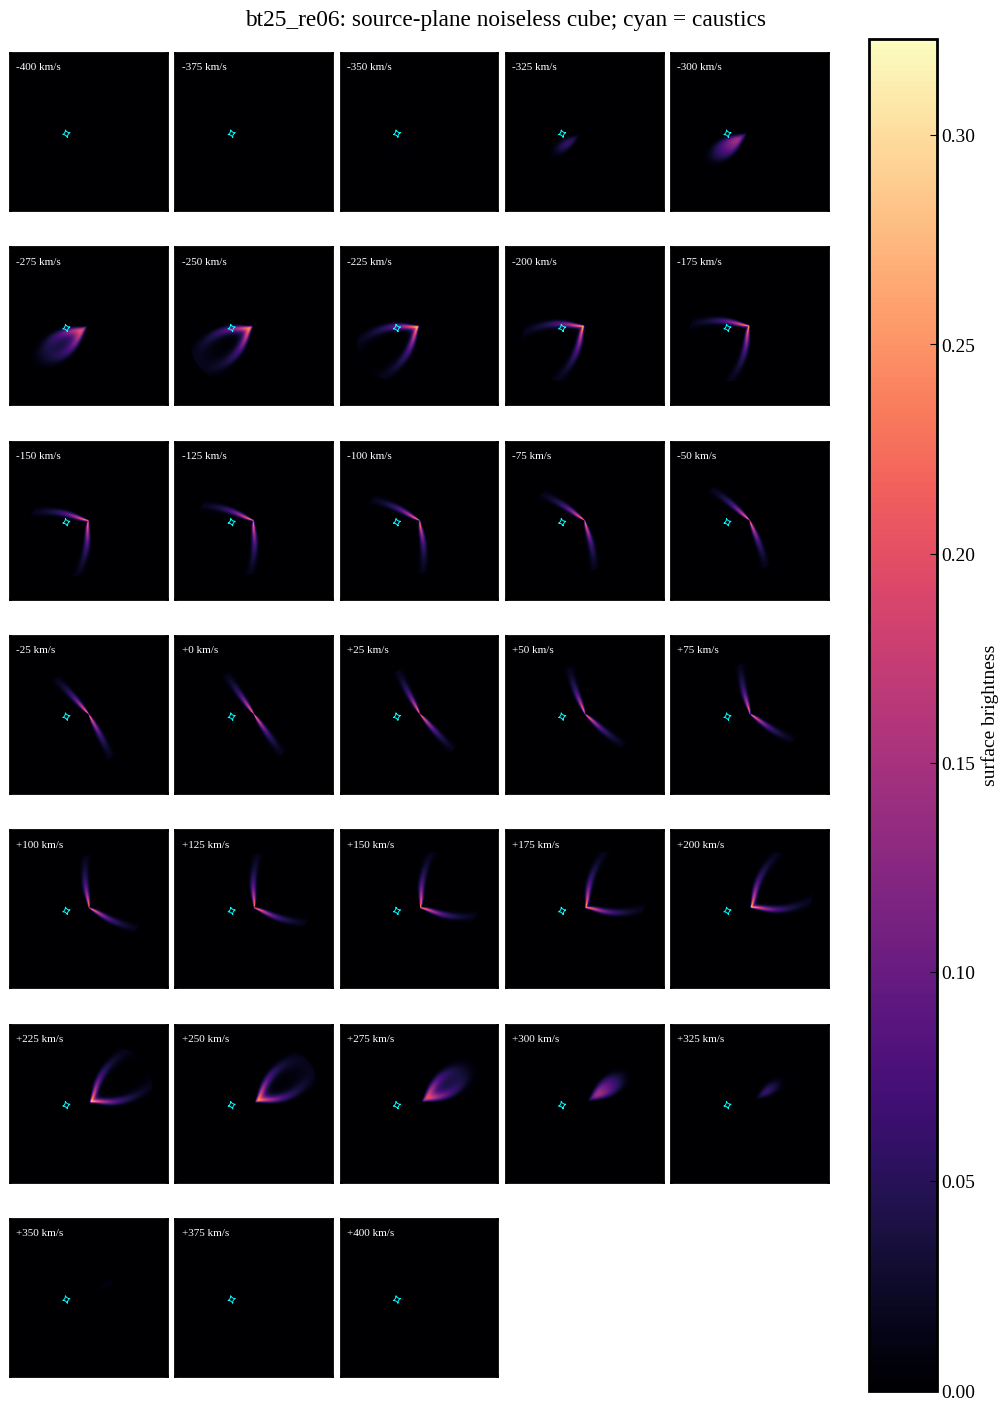

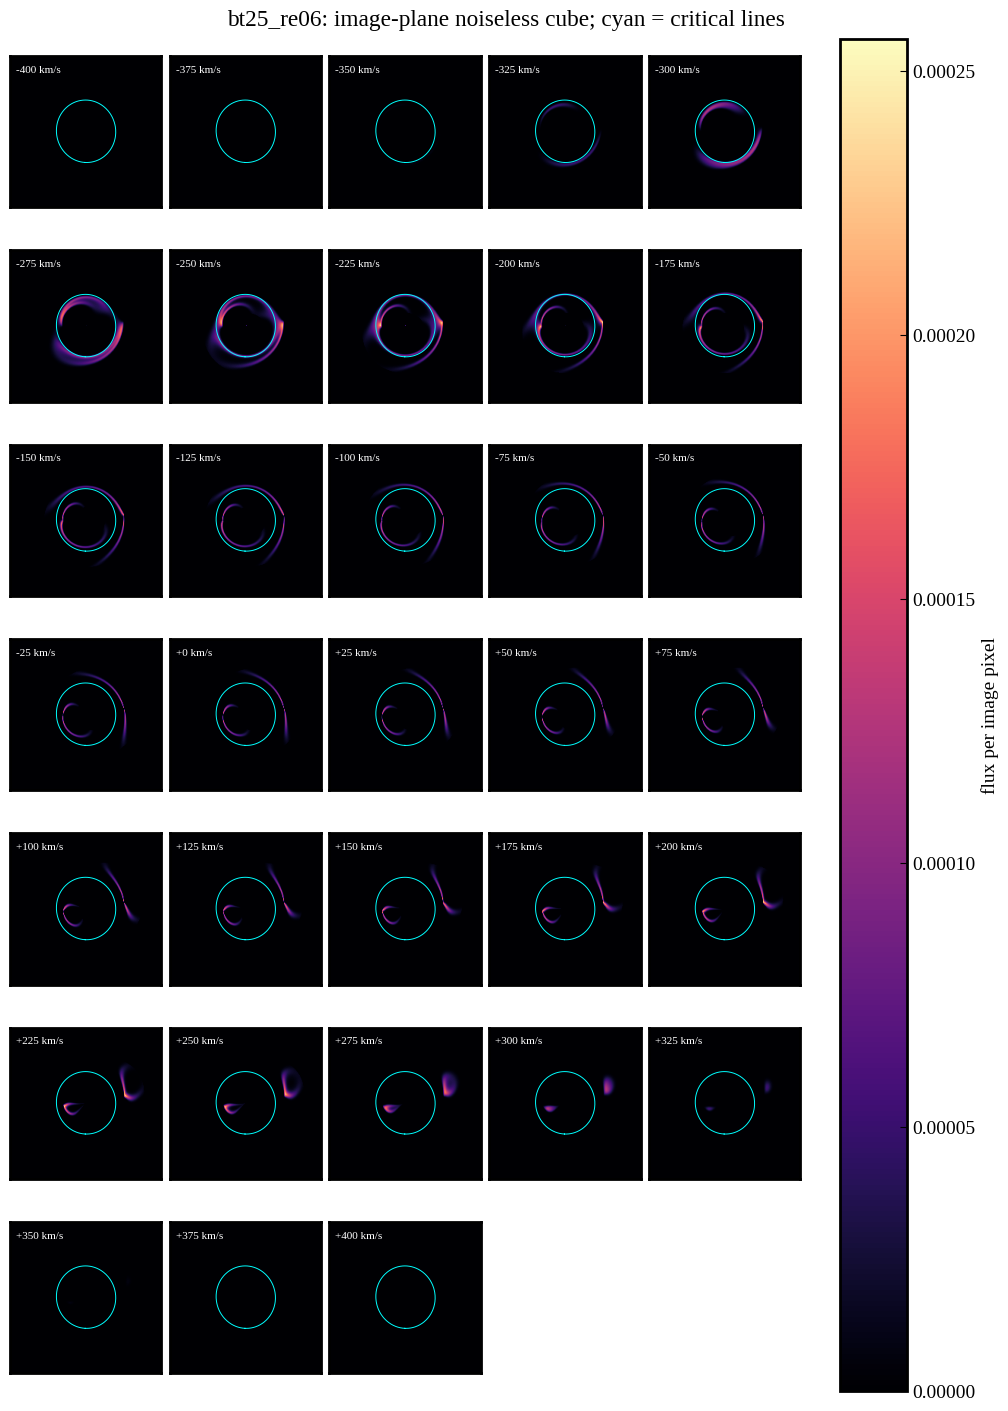

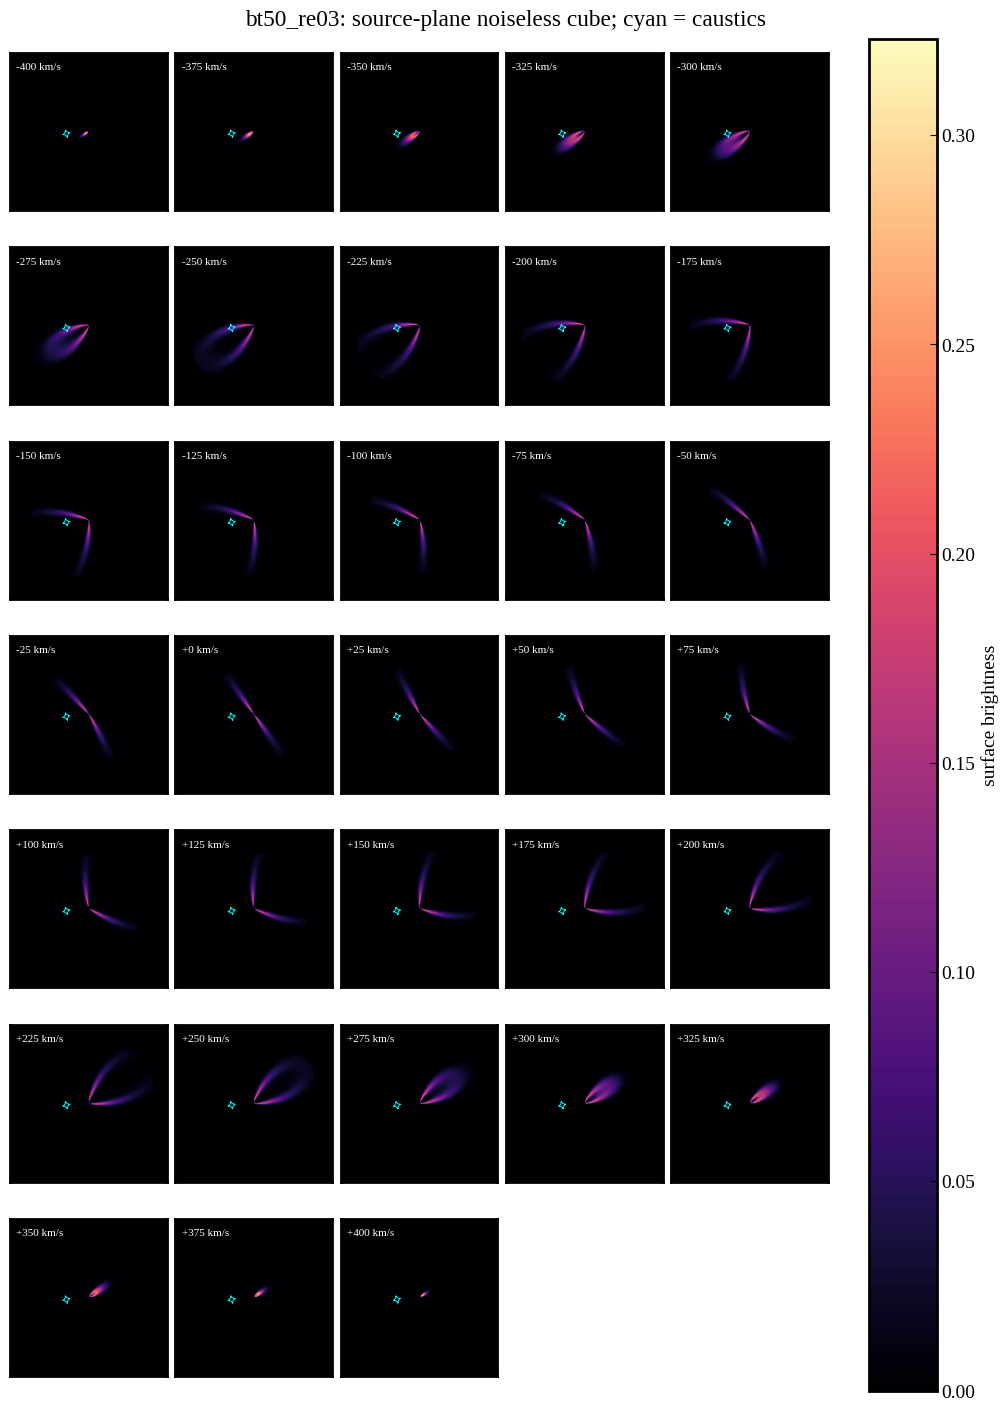

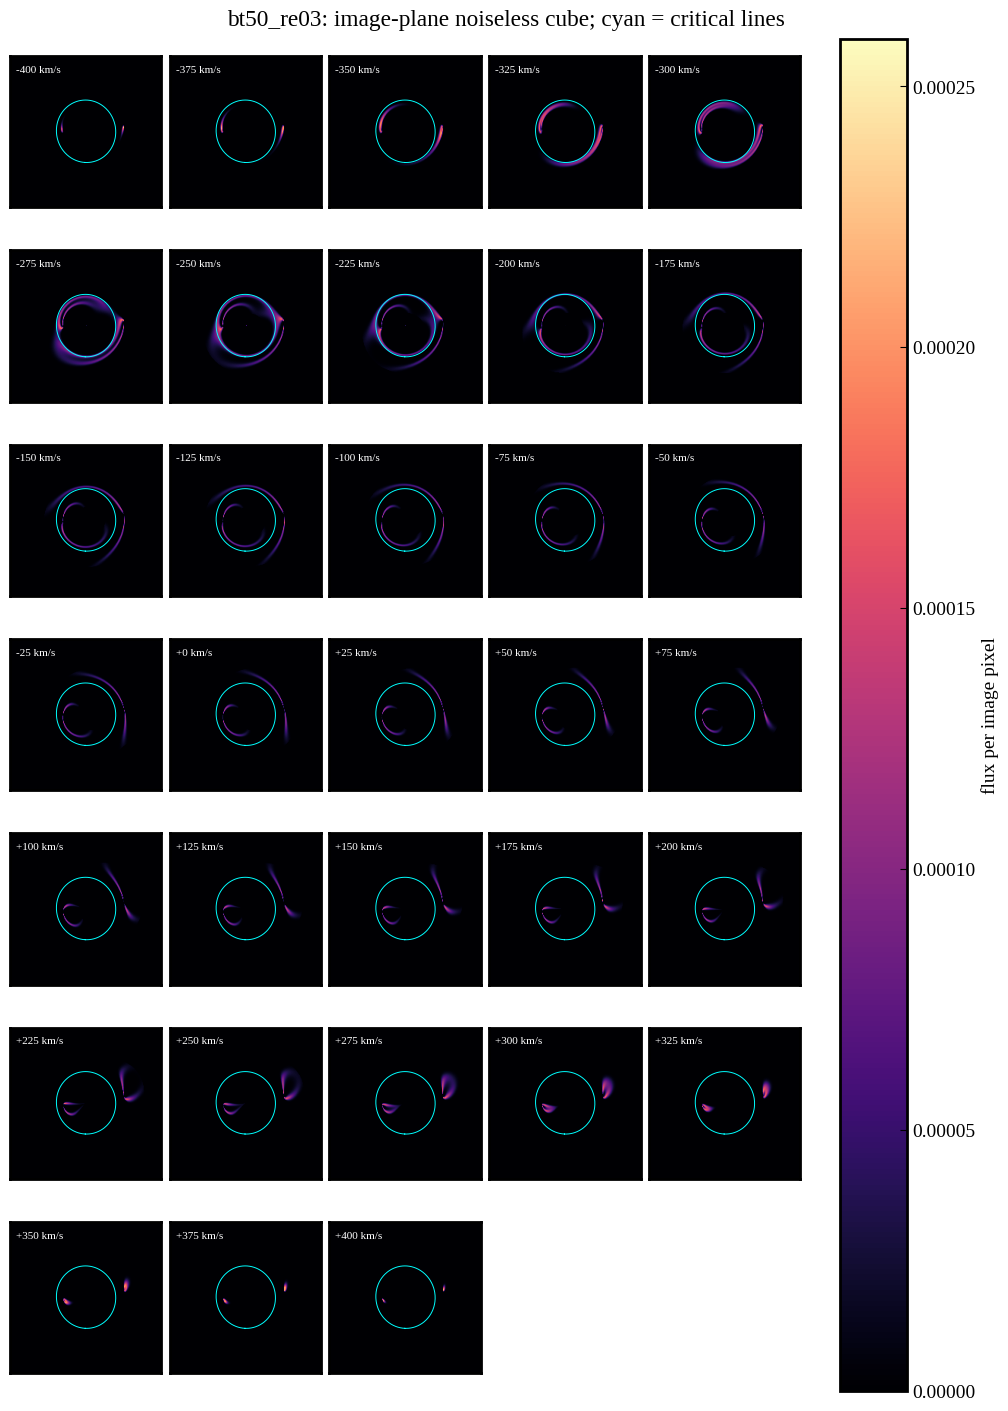

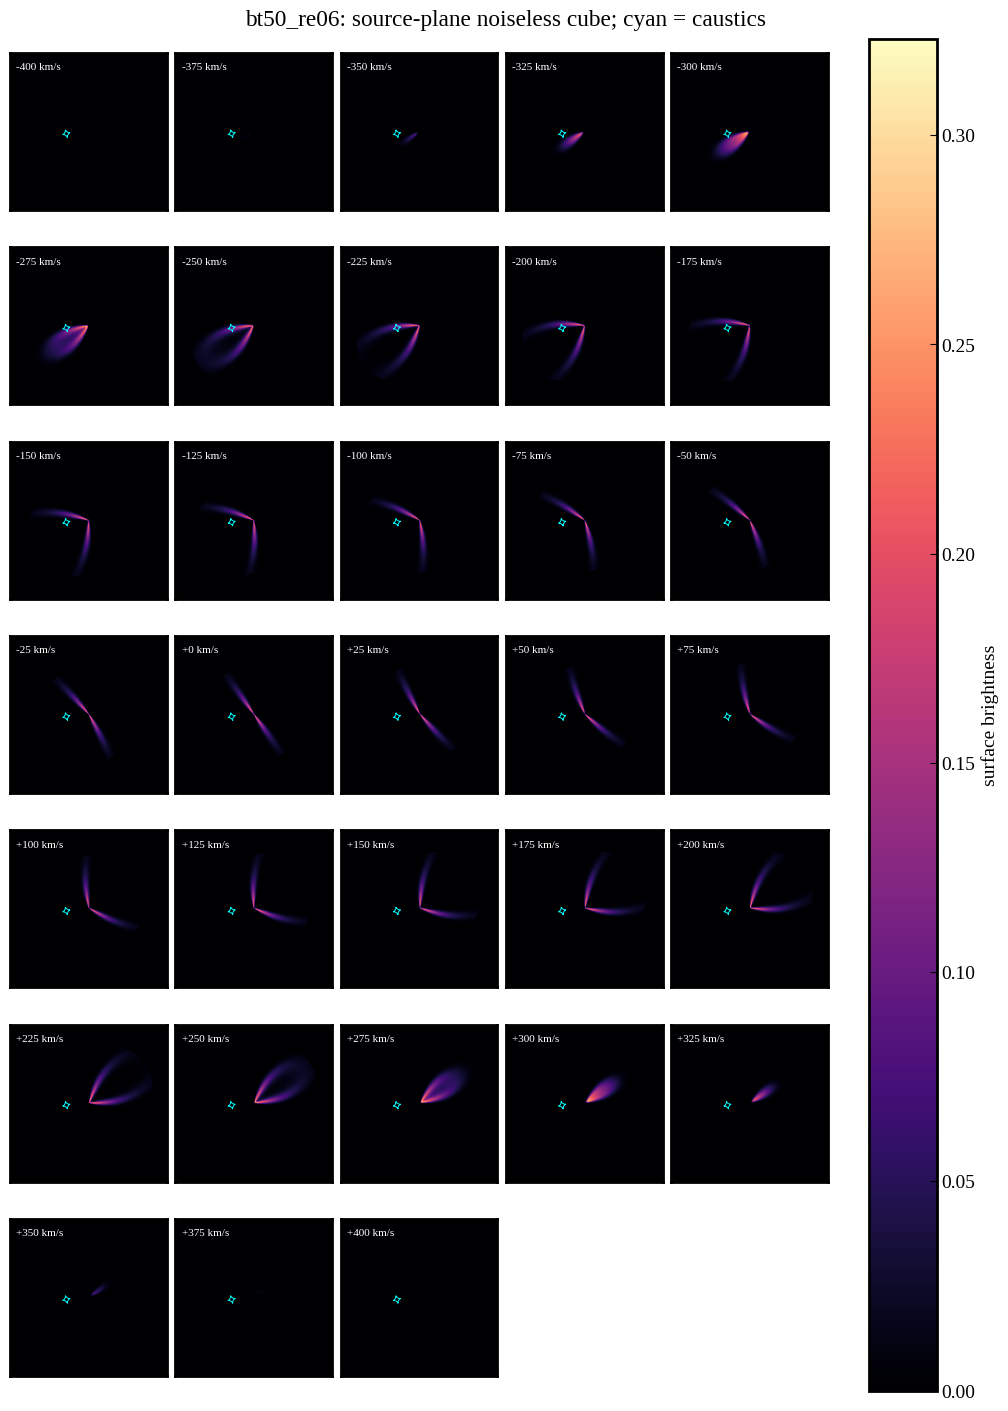

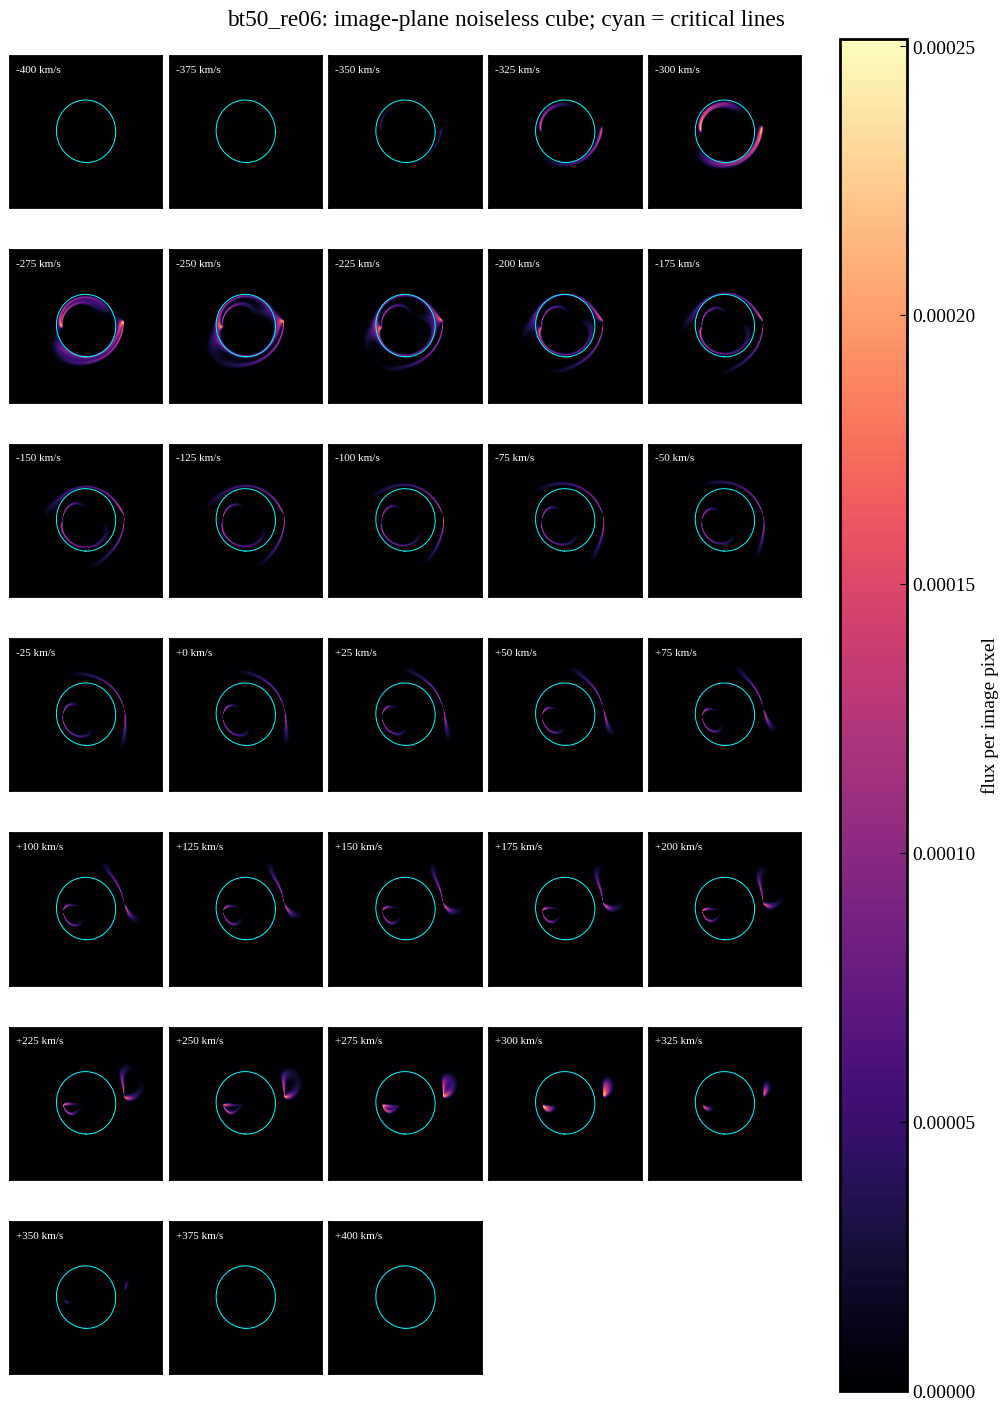

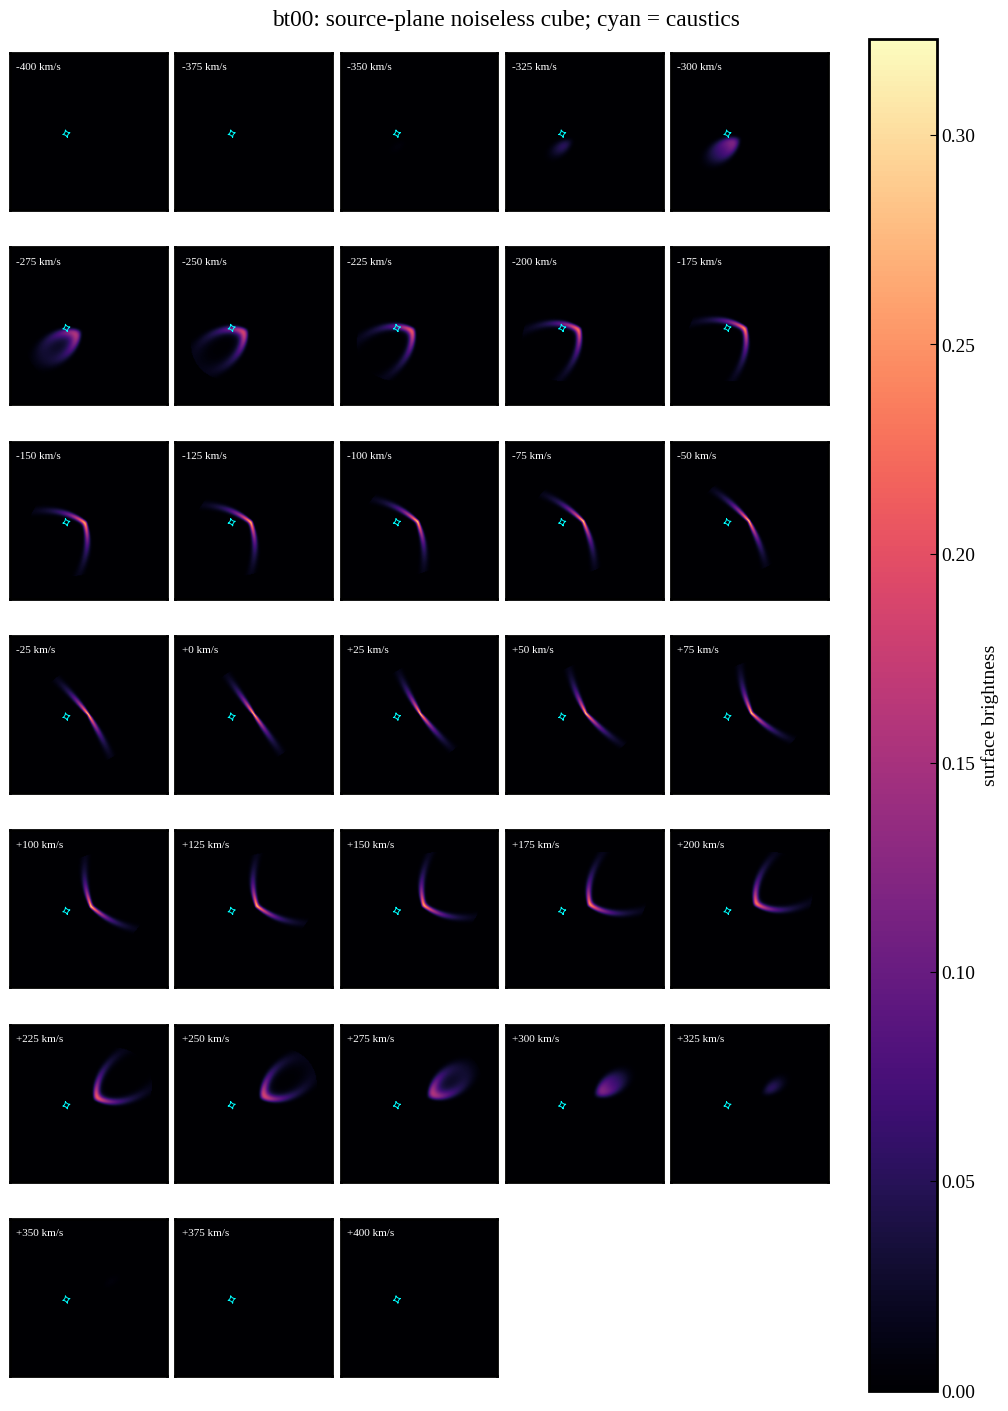

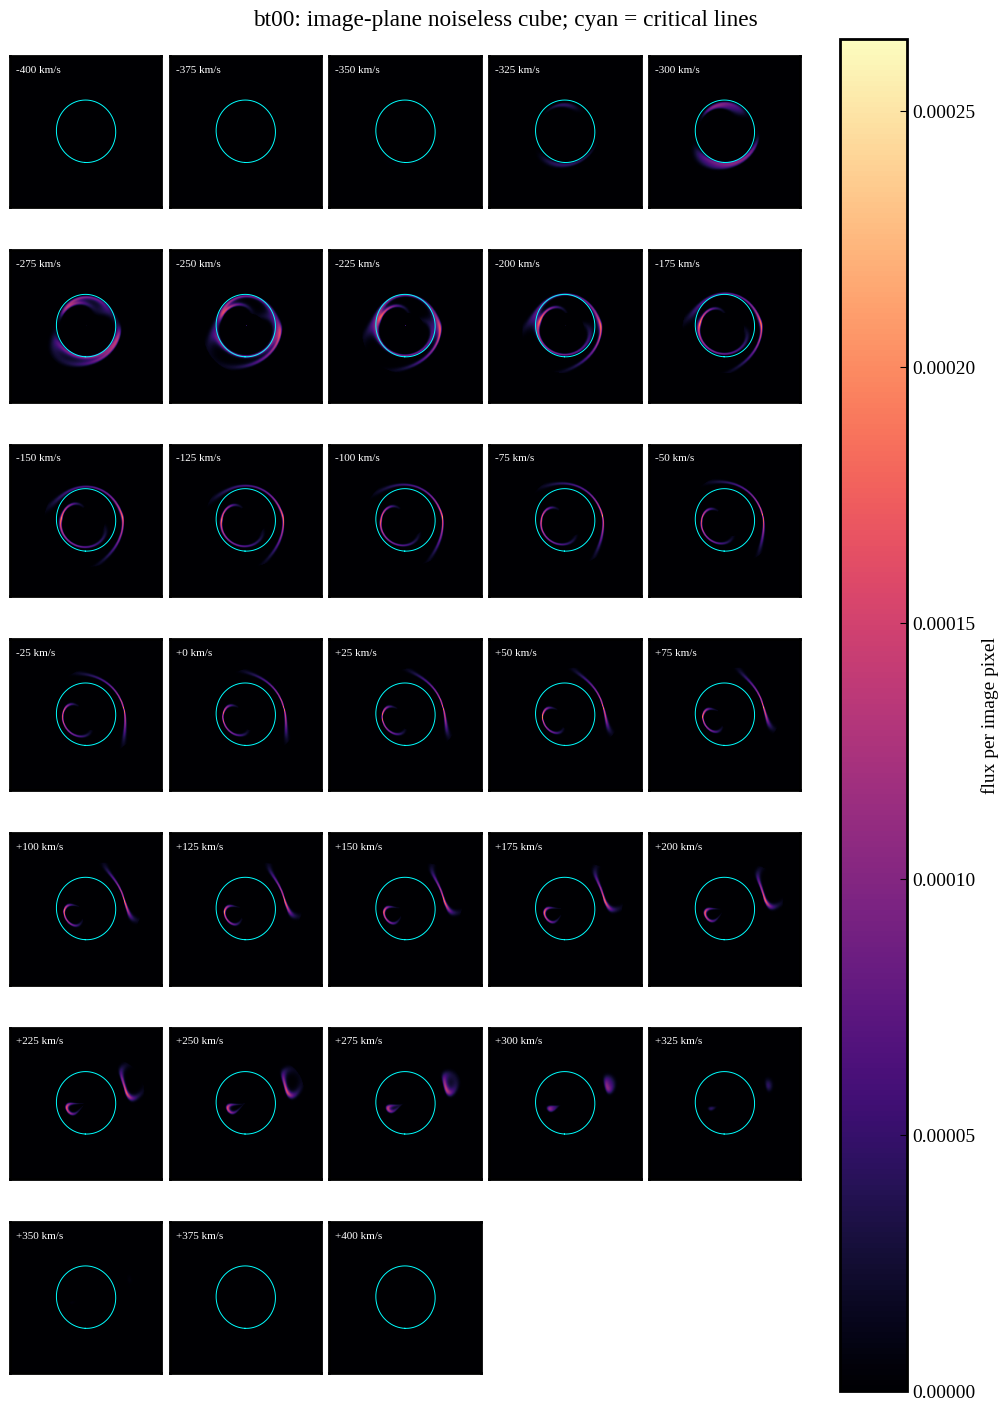

In [11]:
def plot_channel_maps(cube, xx, yy, case_name, plane, curves, curve_label, ncols=5):
    nchan = cube.shape[0]
    nrows = int(np.ceil(nchan / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(2 * ncols, 2 * nrows), constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()
    image = None
    vmax = float(np.nanmax(cube))
    extent = (xx.min(), xx.max(), yy.min(), yy.max())
    for channel, ax in enumerate(axes):
        if channel >= nchan:
            ax.set_visible(False)
            continue
        image = ax.imshow(cube[channel], origin='lower', cmap='magma', vmin=0.0, vmax=vmax, extent=extent)
        for segment in curves:
            ax.plot(segment[:, 0], segment[:, 1], color='cyan', lw=0.7)
        ax.text(
            0.04, 0.94, f'{VELOCITY_CHANNELS_KMS[channel]:+.0f} km/s',
            transform=ax.transAxes, ha='left', va='top', color='white', fontsize=8,
        )
        ax.set_xticks([])
        ax.set_yticks([])
    fig.colorbar(image, ax=axes[:nchan].tolist(), label='surface brightness' if plane == 'source' else 'flux per image pixel')
    fig.suptitle(f'{case_name}: {plane}-plane noiseless cube; cyan = {curve_label}')
    plt.show()

for case in CASES:
    name = case['name']
    plot_channel_maps(
        INTRINSIC_CUBES[name], XX_SOURCE_ARCSEC, YY_SOURCE_ARCSEC,
        name, 'source', CAUSTICS, 'caustics',
    )
    plot_channel_maps(
        LENSED_CUBES[name], XX_IMAGE_ARCSEC, YY_IMAGE_ARCSEC,
        name, 'image', CRITICAL_LINES, 'critical lines',
    )

## Optional check: fixed-lens noiseless recovery

This is a numerical sanity check, not a realistic inference experiment. The noiseless image-plane cube is fitted with bounded least squares using the free parameters selected in `mock_stage1.toml`; every unlisted parameter remains fixed to truth.

This check can reveal inconsistencies between parameter unpacking, source generation, lens mapping, and residual construction. It does **not** demonstrate that the parameters will be identifiable with noise, a finite PSF, or realistic interferometric sampling—that is the purpose of later stages.

The objective is the flattened image-cube residual divided by the cube peak. Different cases are independent and are therefore fitted in parallel.

In [ ]:
RECOVERY_CONFIG = fmc.load_toml(EXAMPLE_DIR / 'mock_stage1.toml')
# Fitが仮定するvertical modelはmock_stage1.tomlから読む（truthの選択は覗かない）。
RECOVERY_MODEL = fmc.build_forward_model(TRUTH_CONFIG, RECOVERY_CONFIG)

FREE_PARAMETER_NAMES = tuple(RECOVERY_CONFIG['recovery']['free_parameters'])
BOUNDS = RECOVERY_CONFIG['bounds']
RECOVERY_LAYOUTS = {
    case['name']: ParameterLayout.compile(
        truth_parameters(case), FREE_PARAMETER_NAMES, BOUNDS,
    )
    for case in CASES
}
REFERENCE_LAYOUT = RECOVERY_LAYOUTS[CASES[0]['name']]
LOWER_BOUNDS = REFERENCE_LAYOUT.prior_lower
UPPER_BOUNDS = LOWER_BOUNDS + REFERENCE_LAYOUT.prior_span
INITIAL_GUESS = np.array([BOUNDS[name]['initial'] for name in FREE_PARAMETER_NAMES])

def free_vector(case):
    return RECOVERY_LAYOUTS[case['name']].encode(truth_parameters(case))

def recover_case(case):
    data_cube = LENSED_CUBES[case['name']]
    scale = float(np.max(data_cube))

    def residual(theta_free):
        # Rebuild the complete source and lensed cube for every optimizer step.
        parameters = RECOVERY_LAYOUTS[case['name']].decode(theta_free)
        try:
            image_model = RECOVERY_MODEL.make_lensed_cube(parameters)
        except UnphysicalPressureSupportError:
            return np.full(data_cube.size, 1e6)
        return ((image_model - data_cube) / scale).ravel()


    fit = run_least_squares(
        residual, INITIAL_GUESS, LOWER_BOUNDS, UPPER_BOUNDS,
        ftol=1e-11, xtol=1e-11, gtol=1e-11, max_nfev=2000,
    )
    best_parameters = RECOVERY_LAYOUTS[case['name']].decode(fit.x)
    best_source_cube = RECOVERY_MODEL.make_intrinsic_cube(best_parameters)
    best_cube = RECOVERY_MODEL.make_lensed_cube(best_parameters)
    # Singular values diagnose local degeneracies in the fitted parameter combination.
    singular_values = np.linalg.svd(fit.jac, compute_uv=False)
    return {
        'truth_free': free_vector(case),
        'best_free': fit.x,
        'best_parameters': best_parameters,
        'best_source_cube': best_source_cube,
        'best_cube': best_cube,
        'max_abs_cube_residual': float(np.max(np.abs(best_cube - data_cube))),
        'success': fit.success,
        'nfev': fit.nfev,
        'jacobian_singular_values': singular_values,
    }


MAX_WORKERS = int(RECOVERY_CONFIG['recovery']['max_workers'])
case_results = run_parallel_fits(recover_case, CASES, max_workers=MAX_WORKERS)
RESULTS = {case['name']: result for case, result in zip(CASES, case_results, strict=True)}
for case in CASES:
    result = RESULTS[case['name']]
    print(
        case['name'], 'success=', result['success'], 'nfev=', result['nfev'],
        'max |cube residual|=', f"{result['max_abs_cube_residual']:.3e}",
    )


In [ ]:
rows = []
for case in CASES:
    best_parameters = RESULTS[case['name']]['best_parameters']
    truth = truth_parameters(case)
    for name in FREE_PARAMETER_NAMES:
        truth_value = getattr(truth, name)
        best = getattr(best_parameters, name)
        if name == 'bulge_effective_radius_kpc' and case['bulge_to_total'] == 0.0:
            truth_value, delta, relative_error = np.nan, np.nan, np.nan
        else:
            delta = best - truth_value
            relative_error = np.nan if truth_value == 0.0 else delta / truth_value
        rows.append((case['name'], name, truth_value, best, delta, relative_error))

RECOVERY_TABLE = Table(
    rows=rows,
    names=('case', 'parameter', 'truth', 'recovered', 'recovered - truth', 'relative error'),
)
for name in RECOVERY_TABLE.colnames[2:]:
    RECOVERY_TABLE[name].format = '.6g'
RECOVERY_TABLE.pprint_all()

   case              parameter             truth  recovered   recovered - truth relative error
--------- -------------------------------- ----- ------------ ----------------- --------------
bt10_re03                   log10_m_baryon    11           11      -9.93521e-08   -9.03201e-09
bt10_re03            disk_scale_radius_kpc     1            1       3.25851e-08    3.25851e-08
bt10_re03                   bulge_to_total   0.1          0.1      -1.76425e-09   -1.76425e-08
bt10_re03       bulge_effective_radius_kpc   0.3          0.3       5.05638e-09    1.68546e-08
bt10_re03                  source_x_arcsec 0.285        0.285      -2.20258e-11   -7.72834e-11
bt10_re03                  source_y_arcsec  0.03         0.03       2.19484e-09    7.31614e-08
bt10_re03               flux_normalization     1            1      -2.60208e-09   -2.60208e-09
bt10_re03                  inclination_deg    45           45       8.53022e-06     1.8956e-07
bt10_re03               position_angle_deg    35  

## Recovery diagnostics

Three complementary diagnostics are shown:

1. a table comparing truth and recovered values for every free parameter;
2. total and component rotation curves, which reveal compensating disk/bulge/halo solutions;
3. truth/model/residual image slices plus the reconstructed intrinsic source.

The Jacobian condition number is also reported. A very large value or very small minimum singular value means that some parameter combinations are locally poorly constrained even when the cube residual is nearly zero.

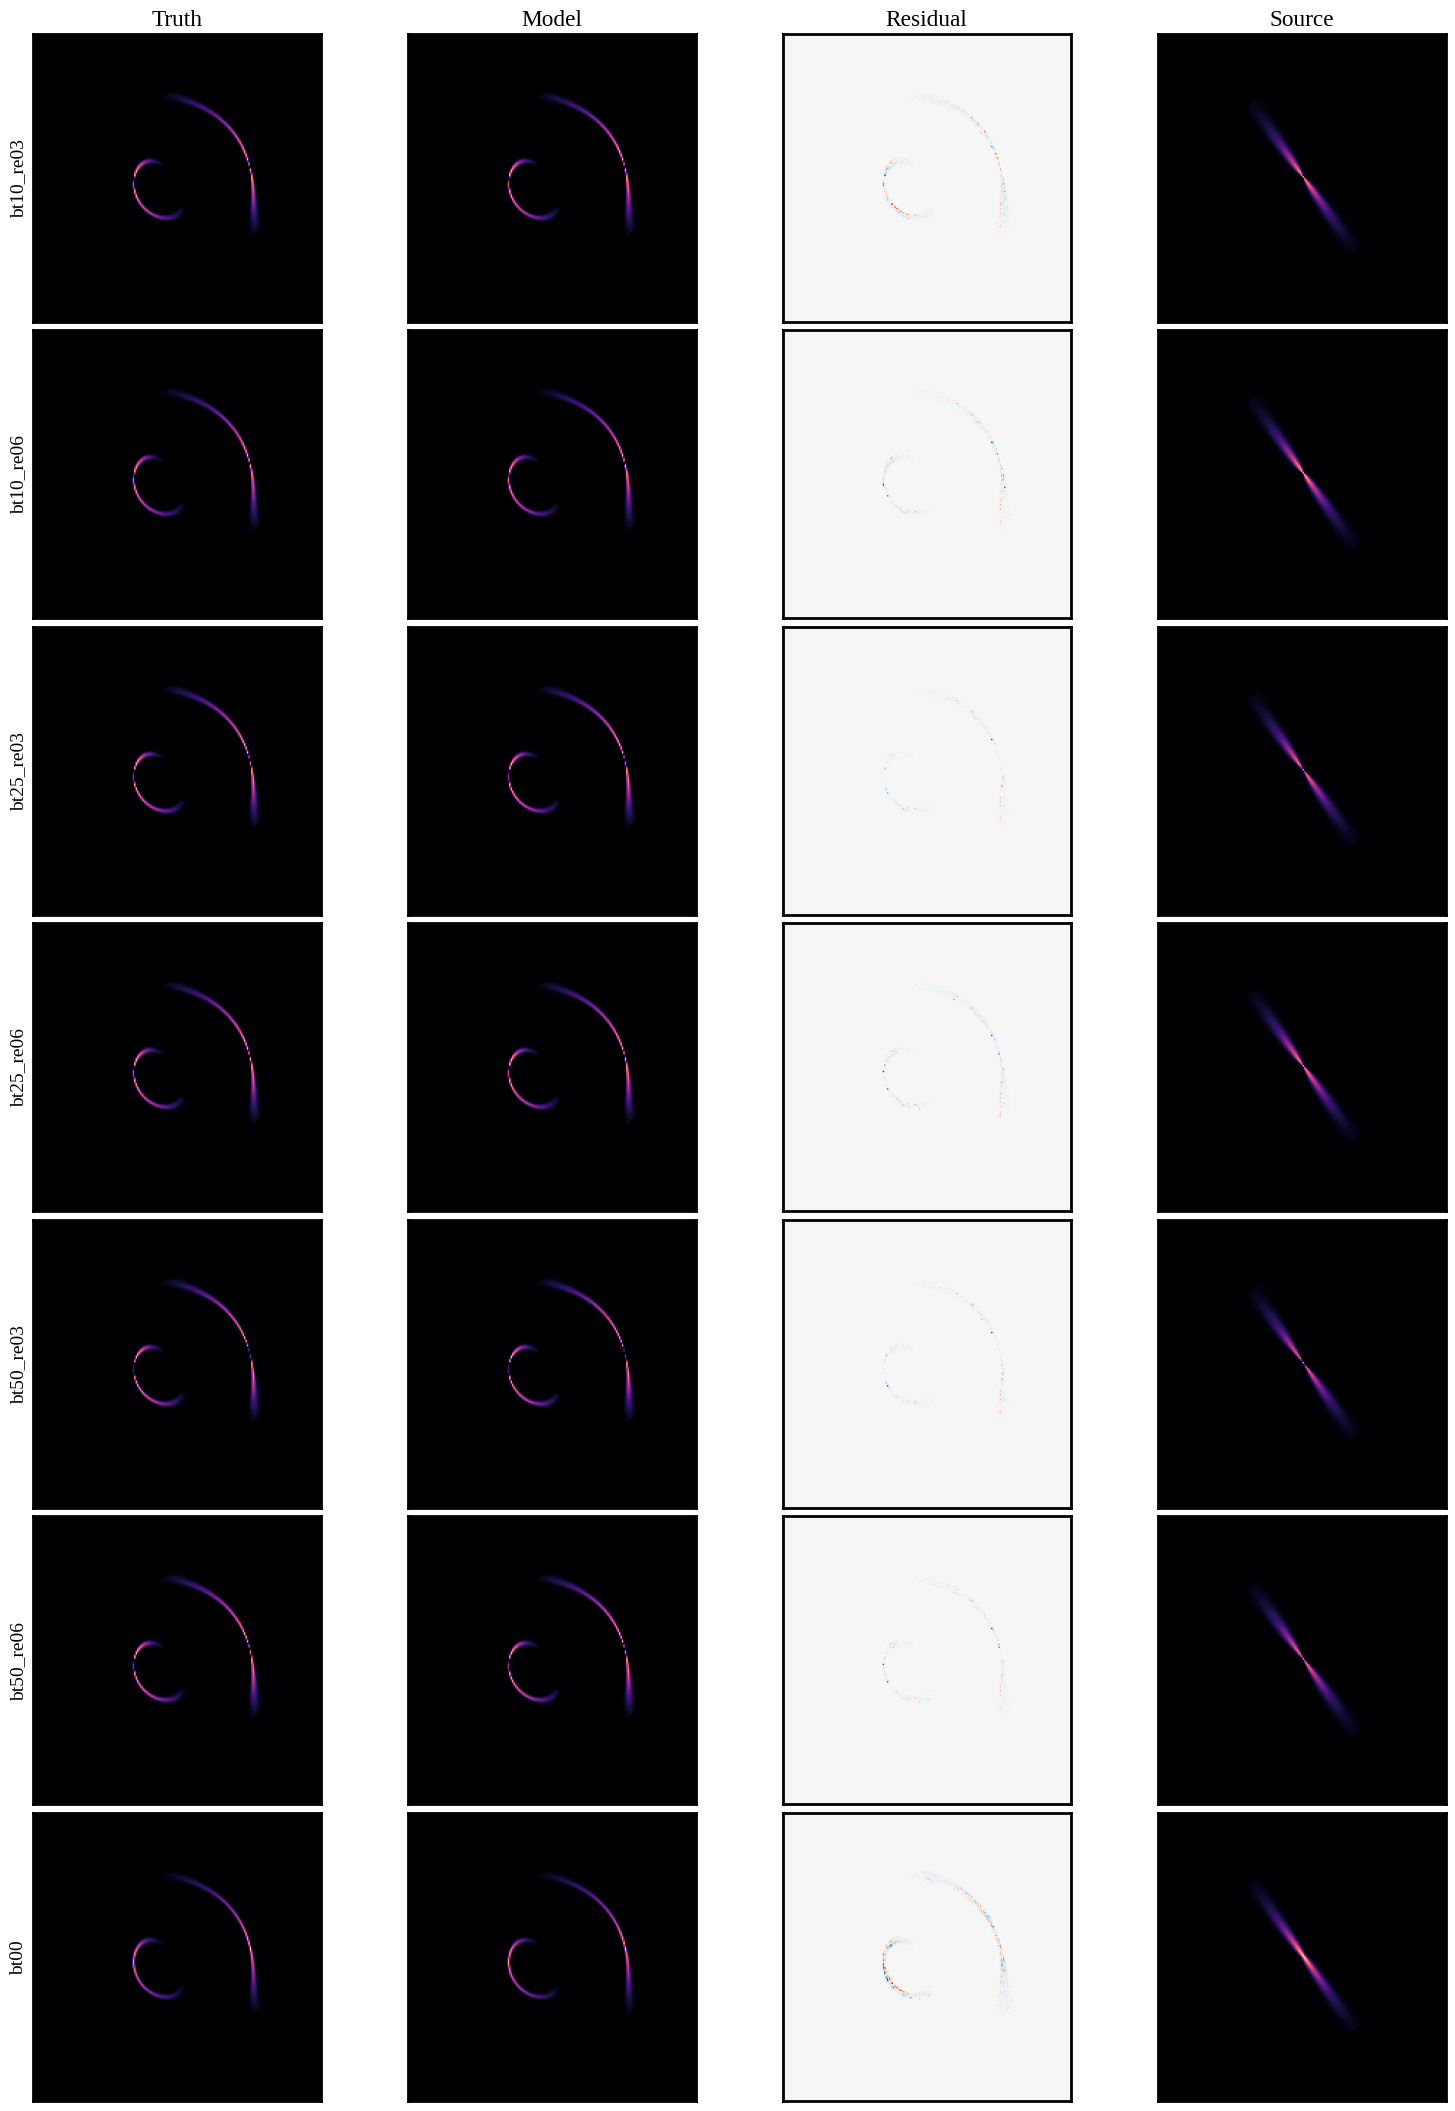

case,Jacobian condition number,smallest singular value
str9,float64,float64
bt10_re03,6457.795066113068,0.22895778851487844
bt10_re06,7098.347751330614,0.2005742899863758
bt25_re03,6383.984067320936,0.2762431373652538
bt25_re06,6542.789306098259,0.23466538400510248
bt50_re03,6851.714975336318,0.3198496794550788
bt50_re06,6272.588254595033,0.27845798172388403
bt00,2.5330129060905092e+16,5.188531838273872e-14


In [ ]:
fig, axes = plt.subplots(
    len(CASES), 4, figsize=(15, 3 * len(CASES)), constrained_layout=True, squeeze=False,
)
identifiability_rows = []
for row, case in enumerate(CASES):
    data_cube = LENSED_CUBES[case['name']]
    best_cube = RESULTS[case['name']]['best_cube']
    best_source_cube = RESULTS[case['name']]['best_source_cube']
    middle = VELOCITY_CHANNELS_KMS.size // 2
    image_extent = (
        XX_IMAGE_ARCSEC.min(), XX_IMAGE_ARCSEC.max(),
        YY_IMAGE_ARCSEC.min(), YY_IMAGE_ARCSEC.max(),
    )
    source_extent = (
        XX_SOURCE_ARCSEC.min(), XX_SOURCE_ARCSEC.max(),
        YY_SOURCE_ARCSEC.min(), YY_SOURCE_ARCSEC.max(),
    )
    vmax = float(np.max(data_cube[middle]))
    axes[row, 0].imshow(data_cube[middle], origin='lower', cmap='magma', vmin=0.0, vmax=vmax, extent=image_extent)
    axes[row, 1].imshow(best_cube[middle], origin='lower', cmap='magma', vmin=0.0, vmax=vmax, extent=image_extent)
    residual = best_cube[middle] - data_cube[middle]
    limit = max(float(np.max(np.abs(residual))), np.finfo(float).eps)
    axes[row, 2].imshow(residual, origin='lower', cmap='RdBu_r', vmin=-limit, vmax=limit, extent=image_extent)
    axes[row, 3].imshow(best_source_cube[middle], origin='lower', cmap='magma', extent=source_extent)
    axes[row, 0].set_ylabel(case['name'])
    if row == 0:
        for ax, title in zip(axes[row], ('Truth', 'Model', 'Residual', 'Source'), strict=True):
            ax.set_title(title)
    for ax in axes[row]:
        ax.set_xticks([])
        ax.set_yticks([])

    singular_values = RESULTS[case['name']]['jacobian_singular_values']
    condition = np.inf if singular_values[-1] == 0 else singular_values[0] / singular_values[-1]
    identifiability_rows.append((case['name'], condition, singular_values[-1]))
plt.show()

Table(
    rows=identifiability_rows,
    names=('case', 'Jacobian condition number', 'smallest singular value'),
)